In [1]:
import torch

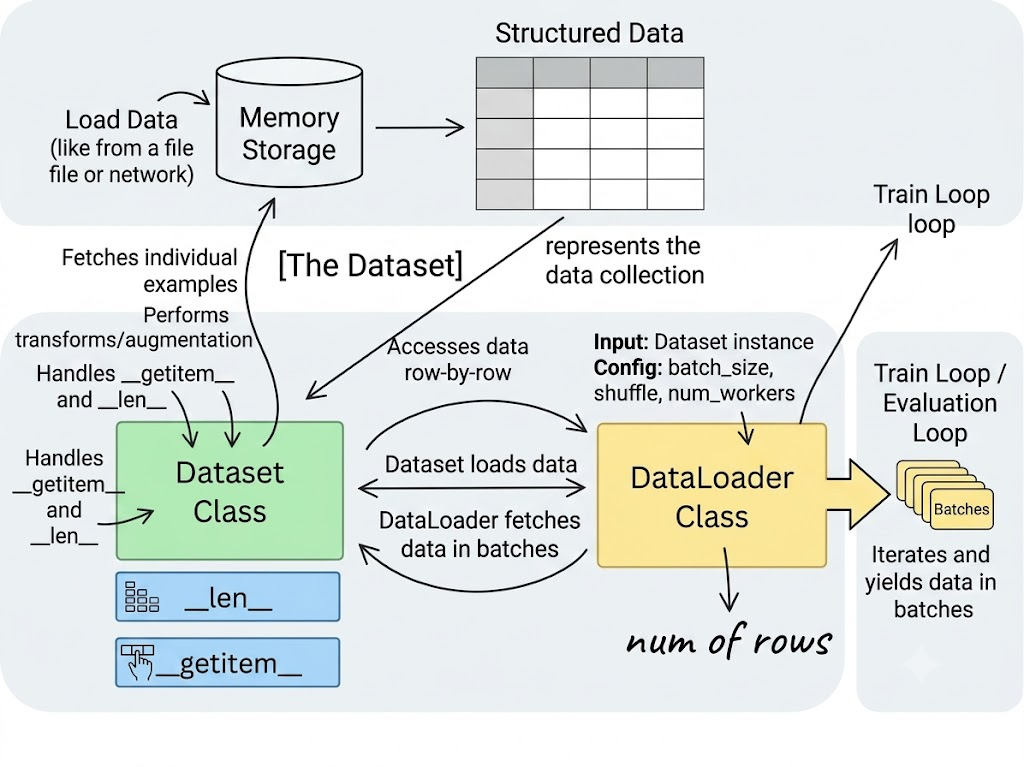

## Dataset Class

The **Dataset** class is essentially a **blueprint**. When you create a custom `Dataset`, you decide **how data is loaded and returned**.

It defines:

* `__init__()` — tells how data should be loaded.
* `__len__()` — returns the total number of samples.
* `__getitem__(index)` — returns the data (and label) at the given index.

---

## DataLoader Class

The **DataLoader** wraps a `Dataset` and handles **batching**, **shuffling**, and **parallel loading** for you.

### DataLoader Control Flow

* At the start of each epoch, the `DataLoader` (if `shuffle=True`) shuffles the indices (using a sampler).
* It divides the indices into chunks of `batch_size`.
* For each index in the chunk, data samples are fetched from the `Dataset` object.



In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=10,       # Number of samples
    n_features=2,       # Number of features
    n_informative=2,    # Number of informative features
    n_redundant=0,      # Number of redundant features
    n_classes=2,        # Number of classes
    random_state=42     # For reproducibility
)

In [3]:
X, y

(array([[ 1.06833894, -0.97007347],
        [-1.14021544, -0.83879234],
        [-2.8953973 ,  1.97686236],
        [-0.72063436, -0.96059253],
        [-1.96287438, -0.99225135],
        [-0.9382051 , -0.54304815],
        [ 1.72725924, -1.18582677],
        [ 1.77736657,  1.51157598],
        [ 1.89969252,  0.83444483],
        [-0.58723065, -1.97171753]]),
 array([1, 0, 0, 0, 0, 1, 1, 1, 1, 0]))

In [4]:
X.shape, y.shape

((10, 2), (10,))

In [5]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long).view(-1, 1)

In [6]:
y.shape

torch.Size([10, 1])

In [7]:
from torch.utils.data import Dataset, DataLoader

In [8]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = features
        self.labels = labels


    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, index):
        # can do apply any transformations on data here
        return self.features[index], self.labels[index]

In [9]:
dataset = CustomDataset(X, y)

In [10]:
len(dataset)

10

In [11]:
dataset[1]

(tensor([-1.1402, -0.8388]), tensor([0]))

In [12]:
dataset[5]

(tensor([-0.9382, -0.5430]), tensor([1]))

In [13]:
dataloader = DataLoader(dataset, batch_size = 2, shuffle = True)

In [14]:
for batch_features, batch_labels in dataloader:
    print(batch_features)
    print(batch_labels)
    print("-"*50)

tensor([[-0.9382, -0.5430],
        [ 1.7774,  1.5116]])
tensor([[1],
        [1]])
--------------------------------------------------
tensor([[-1.1402, -0.8388],
        [ 1.7273, -1.1858]])
tensor([[0],
        [1]])
--------------------------------------------------
tensor([[-2.8954,  1.9769],
        [-0.5872, -1.9717]])
tensor([[0],
        [0]])
--------------------------------------------------
tensor([[ 1.0683, -0.9701],
        [-0.7206, -0.9606]])
tensor([[1],
        [0]])
--------------------------------------------------
tensor([[-1.9629, -0.9923],
        [ 1.8997,  0.8344]])
tensor([[0],
        [1]])
--------------------------------------------------


## DataLoader Parallelization (`num_workers > 0`)

### Why do we need parallelization?

By default, the `DataLoader` loads data **sequentially**.

```text
Load Batch 1 → Train on Batch 1
Load Batch 2 → Train on Batch 2
Load Batch 3 → Train on Batch 3
...
```

While the model is training, the CPU is **not loading the next batch**. Likewise, while the CPU is loading data, the GPU (or CPU running the model) may sit idle. This wastes time.

To reduce this waiting time, PyTorch supports **parallel data loading** using multiple worker processes through the `num_workers` argument.

---

## Example Setup

* Total samples = **10,000**
* Batch size = **32**
* `num_workers = 4`
* Number of batches ≈ **312**

---

## Workflow

### 1. Sampler & Batch Creation (Main Process)

At the start of each epoch:

* Shuffle dataset indices (if `shuffle=True`).
* Split indices into batches of size `batch_size`.
* Place all batches in a queue for the workers.

---

### 2. Parallel Data Loading (Workers)

The DataLoader distributes the first batches among the workers.

Example:

* Worker 1 → Batch 1
* Worker 2 → Batch 2
* Worker 3 → Batch 3
* Worker 4 → Batch 4

Each worker:

* Calls `Dataset.__getitem__()` for every sample in its assigned batch.
* Applies transforms (if any).
* Uses `collate_fn` to combine samples into a batch tensor.

---

### 3. First Batch Returned

The first worker that finishes sends its completed batch to the **main process**.

Your training loop receives it as

```python
for batch_data, batch_labels in dataloader:
    ...
```

---

### 4. Model Training

The main process performs:

1. Forward pass
2. Loss computation
3. Backward pass
4. Optimizer step

At the **same time**, the other workers continue preparing the remaining batches.

---

### 5. Continuous Pipeline

Whenever a worker finishes a batch, it immediately starts loading the next available batch.

Example:

* Worker 1 finishes Batch 1 → Starts Batch 5
* Worker 2 finishes Batch 2 → Starts Batch 6
* Worker 3 finishes Batch 3 → Starts Batch 7
* Worker 4 finishes Batch 4 → Starts Batch 8

Thus, several batches are always being prepared while the model trains.

---

### 6. Training Loop Perspective

Your code remains simple:

```python
for batch_data, batch_labels in dataloader:
    # Forward pass
    # Compute loss
    # Backward pass
    # Optimizer step
```

Behind the scenes, DataLoader continuously preloads future batches in parallel.

---

### 7. End of Epoch

* All batches are processed.
* DataLoader stops yielding batches.
* If `shuffle=True`, indices are reshuffled and the process repeats for the next epoch.

---


## Samplers in PyTorch

### What is a Sampler?

A **Sampler** determines **which sample indices** are selected from a `Dataset` during data loading.

Instead of returning the actual data, the sampler returns the **indices**, and the `DataLoader` uses these indices to fetch the corresponding samples from the dataset.

---

## Types of Samplers

### 1. `SequentialSampler`

* Returns indices **sequentially** in the order they appear in the dataset.
* Default when:

  ```python
  shuffle=False
  ```
* Example:

  ```text
  Dataset indices: 0, 1, 2, 3, 4, 5
  Returned order:  0, 1, 2, 3, 4, 5
  ```

---

### 2. `RandomSampler`

* Returns indices **randomly** (without replacement by default).
* Default when:

  ```python
  shuffle=True
  ```
* Example:

  ```text
  Dataset indices: 0, 1, 2, 3, 4, 5
  Returned order:  3, 0, 5, 1, 4, 2
  ```

---

### 3. `Custom Sampler`

* A **Custom Sampler** allows you to define your own strategy for selecting sample indices.
* Used when the default sequential or random sampling does not meet your requirements.

**Common use cases:**

* Handling **imbalanced datasets** by oversampling minority classes.
* Creating balanced batches.
* Sampling only a subset of the dataset.
* Implementing custom sampling strategies for research.

> **Note:** For imbalanced datasets, PyTorch already provides **`WeightedRandomSampler`**, which is the most commonly used sampler. It assigns **higher sampling probabilities** to minority-class samples so they are selected more frequently during training, helping the model learn from underrepresented classes.




## `collate_fn` in PyTorch

### What is `collate_fn`?

`collate_fn` is a function used by the **DataLoader** to **combine individual samples into a single batch**.

By default, the DataLoader uses a simple collation function that stacks samples into tensors. However, `collate_fn` allows you to **customize how data is processed and batched** before it is returned by the DataLoader.

---

## Why do we need `collate_fn`?

The default `collate_fn` works well when **all samples have the same shape**.

Example:

```text
Image 1 → (3, 224, 224)
Image 2 → (3, 224, 224)
Image 3 → (3, 224, 224)
```

These can be stacked directly into:

```text
Batch → (3, 3, 224, 224)
```

---

## When is a custom `collate_fn` needed?

A custom `collate_fn` is required when samples **cannot be stacked directly**.

> **Within a single tensor, every dimension must have a consistent size.**

**Example: Text Data**

```text
Sentence                  Token IDs
"I love coding"           [1, 2, 3]
"Deep learning rocks"     [4, 5, 6]
"Transformers are fun"    [7, 8, 9, 10]
"Hello world"             [11, 12]
```

Each sentence has a **different length**, so the default DataLoader cannot stack them into a tensor.

---

## Common Solution: Padding

A custom `collate_fn` pads shorter sequences so that all sequences in a batch have the same length.

Example:

```text
Original:
[1, 2, 3]
[4, 5, 6]
[7, 8, 9, 10]
[11, 12]

After Padding:
[1, 2, 3, 0]
[4, 5, 6, 0]
[7, 8, 9,10]
[11,12, 0, 0]
```

Now they can be stacked into a single tensor.





# Important DataLoader Parameters

### 1. `dataset` (Required)

* The dataset from which the `DataLoader` loads data.
* Must be a subclass of `torch.utils.data.Dataset` implementing `__getitem__()` and `__len__()`.

---

### 2. `batch_size`

* Number of samples in each batch.
* Default: `1`.
* Larger batch sizes improve throughput but require more memory.

---

### 3. `shuffle`

* If `True`, shuffles the dataset at the start of every epoch.
* Helps prevent the model from learning the order of the data.

---

### 4. `num_workers`

* Number of worker processes used for parallel data loading.
* `num_workers > 0` speeds up data loading by utilizing multiple CPU cores.

---

### 5. `pin_memory`

* If `True`, stores batches in **pinned (page-locked) memory** before returning them.
* Speeds up data transfer from **CPU to GPU**.
* Mainly useful when training on **CUDA-enabled GPUs**.

---

### 6. `drop_last`

* If `True`, discards the last batch if it has fewer than `batch_size` samples.
* Useful when all batches must have the same size (e.g., Batch Normalization).

---

### 7. `collate_fn`

* Specifies **how individual samples are combined into a batch**.
* Custom `collate_fn` is useful for variable-length data (e.g., text sequences) or custom batching logic.

---

### 8. `sampler`

* Defines **how sample indices are selected** from the dataset.
* Useful for custom sampling strategies (e.g., `WeightedRandomSampler` for imbalanced datasets).
* Typically, you don't specify `sampler` if you're already using `shuffle=True`; the DataLoader chooses an appropriate sampler automatically.
